<a href="https://colab.research.google.com/github/MarkowitzMx/Programacion-para-analitica-descriptiva-y-predictiva-2026/blob/main/Copy_of_Sesion12__Analisis_Descriptivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Cristóbal Lemus Rendón
- **Matrícula:** 274690

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [2]:
# 1.1 — Calculamos media, mediana y moda de la columna 'price'

media_price = df['price'].mean()      # promedio aritmético: suma de todos los precios / número de listados
mediana_price = df['price'].median()  # valor que queda justo en medio al ordenar todos los precios
moda_price = df['price'].mode()[0]    # valor que más se repite en la columna (mode() puede devolver varios, tomamos el primero)

print(f"Media:   {media_price:.2f}")
print(f"Mediana: {mediana_price:.2f}")
print(f"Moda:    {moda_price:.2f}")

# Revisamos también el máximo y el mínimo, ya que nos serán útiles para
# justificar la conclusión de 1.2 (ver si hay valores extremos)
print(f"\nMínimo:  {df['price'].min()}")
print(f"Máximo:  {df['price'].max()}")


Media:   152.72
Mediana: 106.00
Moda:    100.00

Mínimo:  0
Máximo:  10000


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_

La media de `price` es **\$152.72** y la mediana es **\$106.00** — divergen de forma importante: la media es casi un 44% más alta que la mediana ($46.72 de diferencia). Esto es la misma señal que vimos en clase con `Income`: cuando la media está claramente por encima de la mediana, es porque un grupo relativamente pequeño de valores muy altos está "jalando" el promedio hacia arriba, mientras que la mediana —al no verse afectada por la magnitud de los extremos, solo por su posición— refleja mejor el precio "típico" de un listado.

La moda es **\$100**, un valor cercano a la mediana (\$106), lo cual refuerza la idea de que la mayoría de los listados se concentran en un rango de precios moderado (decenas de dólares), y que son unos pocos listados con precios extremadamente altos (el máximo de la columna es **\$10,000**, frente a un mínimo de $0) los que distorsionan la media. En otras palabras, esta divergencia media-mediana sugiere fuertemente la presencia de **valores atípicos (outliers) hacia la derecha** de la distribución, tal como ocurría con `Income` en clase.


---
## Actividad 2 — Dispersión (20 pts)

In [ ]:
# 2.1 — Calculamos rango, varianza, desviación estándar e IQR de 'price'

rango_price = df['price'].max() - df['price'].min()  # rango = valor máximo - valor mínimo
varianza_price = df['price'].var()                    # varianza: promedio de las desviaciones al cuadrado respecto a la media
std_price = df['price'].std()                         # desviación estándar: raíz cuadrada de la varianza (misma unidad que 'price', dólares)

# Para el IQR necesitamos los cuartiles Q1 (percentil 25) y Q3 (percentil 75)
q1_price = df['price'].quantile(0.25)
q3_price = df['price'].quantile(0.75)
iqr_price = q3_price - q1_price  # IQR: rango donde se concentra el 50% central de los datos

print(f"Rango:               {rango_price:.2f}")
print(f"Varianza:            {varianza_price:.2f}")
print(f"Desviación estándar: {std_price:.2f}")
print(f"Q1 (percentil 25):   {q1_price:.2f}")
print(f"Q3 (percentil 75):   {q3_price:.2f}")
print(f"IQR (Q3 - Q1):       {iqr_price:.2f}")


Rango:               10000.00
Varianza:            57674.03
Desviación estándar: 240.15
Q1 (percentil 25):   69.00
Q3 (percentil 75):   175.00
IQR (Q3 - Q1):       106.00


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_

El **rango** de `price` es \$10,000 (de \$0 a \$10,000), mientras que el **IQR** es apenas **\$106** (de \$69 en Q1 a \$175 en Q3). La diferencia es enorme: el rango es casi 100 veces más grande que el IQR.

El **IQR es claramente la medida más representativa** de la dispersión "típica" de los precios. El rango depende únicamente de los dos valores extremos de toda la columna (mínimo y máximo), y basta con que exista **un solo listado** con un precio absurdamente alto —en este caso, \$10,000 por noche, un valor casi imposible de sostener para un Airbnb normal y casi con certeza un outlier o un error de captura— para que el rango se dispare y deje de reflejar cómo se comporta la mayoría de los datos. El IQR, en cambio, ignora por construcción el 25% más bajo y el 25% más alto, quedándose solo con el "núcleo" central de la distribución: \$69 y \$175 por noche, un rango mucho más creíble y útil para describir el precio "típico" que el rango completo, que está totalmente dominado por el valor extremo de \$10,000.

---
## Actividad 3 — Forma (20 pts)

In [3]:
# 3.1 — Calculamos la asimetría (skew) y la curtosis (kurt) de 'price'

skew_price = df['price'].skew()  # asimetría: mide qué tan simétrica es la distribución alrededor de la media
                                   # (0 = simétrica; positivo = cola larga hacia la derecha, valores altos atípicos)
kurt_price = df['price'].kurt()   # curtosis: mide qué tan "pesadas" son las colas de la distribución comparadas
                                   # con una normal (curtosis de exceso; 0 = como una normal; valores grandes = colas muy pesadas)

print(f"Asimetría (skew): {skew_price:.2f}")
print(f"Curtosis (kurt):  {kurt_price:.2f}")


Asimetría (skew): 19.12
Curtosis (kurt):  585.67


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:_

Los valores de `price` son **todavía más extremos** que los de `Income` en clase: obtuve una asimetría de **19.12** (frente a 6.76 de `Income`) y una curtosis de **585.67** (frente a 159.6 de `Income`). Es decir, `price` tiene casi 3 veces la asimetría y más de 3.5 veces la curtosis que la variable de referencia vista en clase — y `Income` ya se consideraba un caso fuerte de distribución no normal debido a un outlier.

Una asimetría de 19.12 (muy por encima de 0, y muy por encima incluso del +1 que ya se considera "alta asimetría positiva") confirma que la distribución de `price` tiene una **cola derecha extremadamente larga**: la inmensa mayoría de los precios están concentrados en valores bajos-moderados, pero existen listados con precios excepcionalmente altos (como el máximo de $10,000 encontrado en la Actividad 2) que estiran la distribución hacia la derecha. Una curtosis de 585.67 (muchísimo mayor que 0, que sería el valor de una distribución normal) indica colas extremadamente "pesadas": hay una probabilidad mucho mayor de encontrar valores muy alejados de la media de lo que una distribución normal predeciría.

Estos valores anticipan directamente lo que se va a trabajar en la etapa de **Datos Atípicos**: una asimetría y curtosis tan altas son básicamente una alerta estadística de que la columna `price` contiene **outliers severos** que habrá que detectar (por ejemplo, con el método de IQR o z-scores) y decidir cómo tratar (winsorizar, transformar con logaritmo, o eliminar/investigar los casos extremos) antes de usar esta variable en cualquier análisis o modelo que asuma una distribución más simétrica.


---
## Actividad 4 — Visualización (30 pts)

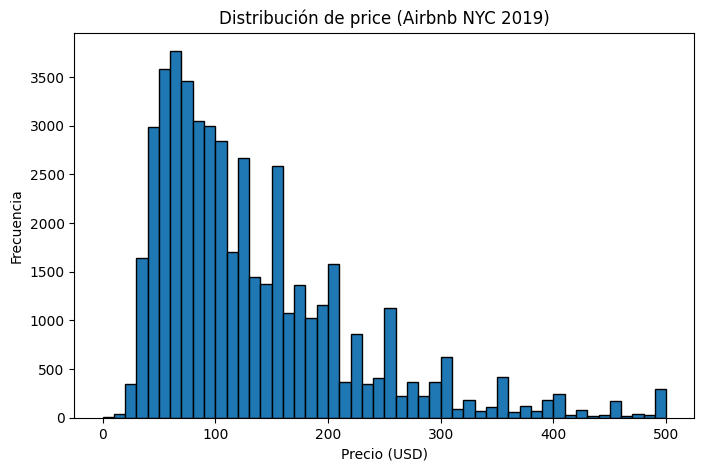

In [4]:
# 4.1 — Histograma de 'price' usando .plot(kind='hist')

# Elegimos limitar el eje x a un rango razonable (0 a 500) usando el parámetro 'range',
# ya que sabemos por la Actividad 2 que el 75% de los precios está por debajo de $175
# y el máximo es un outlier extremo de $10,000: sin este recorte, el histograma
# completo se vería como una sola barra pegada al 0 y no se apreciaría la forma real
# de la distribución. Usamos 50 bins para tener suficiente detalle sin que se vea
# demasiado ruidoso (con muchos menos bins se pierden matices; con muchos más,
# el histograma se ve demasiado fragmentado para un rango de 500 unidades)
df['price'].plot(kind='hist', bins=50, range=(0, 500), figsize=(8, 5),
                  title='Distribución de price (Airbnb NYC 2019)', edgecolor='black')
plt.xlabel('Precio (USD)')
plt.ylabel('Frecuencia')
plt.show()


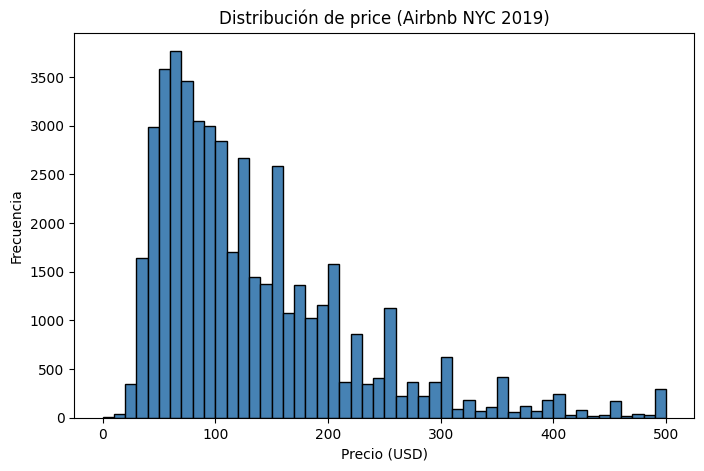

In [ ]:
# 4.2 — Mismo histograma construido directamente con matplotlib.pyplot (plt.hist())

plt.figure(figsize=(8, 5))
# Usamos el mismo recorte (0 a 500) y el mismo número de bins (50) que en 4.1
# para que ambos histogramas sean comparables entre sí
plt.hist(df['price'], bins=50, range=(0, 500), edgecolor='black', color='steelblue')
plt.title('Distribución de price (Airbnb NYC 2019)')  # título del gráfico
plt.xlabel('Precio (USD)')                             # etiqueta del eje x
plt.ylabel('Frecuencia')                               # etiqueta del eje y
plt.show()


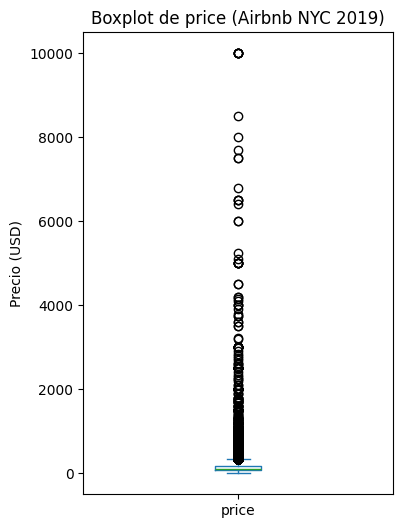

In [5]:
# 4.3 — Boxplot de 'price'

# Usamos la columna completa (sin recortar el rango) precisamente porque el boxplot,
# a diferencia del histograma, está diseñado para mostrar los outliers como puntos
# individuales más allá de los "bigotes" (whiskers) -- recortar el rango aquí
# ocultaría justo la información que este gráfico debe revelar
df['price'].plot(kind='box', figsize=(4, 6), title='Boxplot de price (Airbnb NYC 2019)')
plt.ylabel('Precio (USD)')
plt.show()


**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tu respuesta:_

En el **histograma** (4.1 y 4.2), incluso limitando el eje x al rango 0-500, se observa una distribución fuertemente concentrada en precios bajos (la mayoría de las barras más altas están entre 50 y 150) con una cola larga que se va adelgazando hacia la derecha — es justo la forma que anticipa una asimetría positiva tan alta (19.12) como la calculada en la Actividad 3. Sin embargo, el histograma **no muestra directamente el outlier de \$10,000** ni otros valores extremos, porque tuvimos que recortar el eje x a propósito; si no lo hubiéramos hecho, esos outliers habrían aplastado visualmente el resto de la distribución en una sola barra pegada al cero, volviendo el gráfico ilegible.

En el **boxplot** (4.3), en cambio, los outliers son **mucho más evidentes**: aparecen como una gran cantidad de puntos individuales por encima del bigote superior, extendiéndose claramente hasta cerca de \$10,000, mientras que la "caja" central (que representa el IQR calculado en la Actividad 2: de \$69 a \$175) se ve muy comprimida en la parte baja del gráfico en comparación con la nube de puntos atípicos.

En conclusión, **los outliers se distinguen mucho mejor en el boxplot** que en el histograma, precisamente porque el boxplot está diseñado para señalarlos explícitamente usando el criterio de IQR (puntos más allá de 1.5×IQR de los cuartiles), mientras que en el histograma su presencia solo se infiere indirectamente (obligándonos a recortar el eje o a notar que casi no hay barras visibles más allá de cierto punto). Esto es completamente consistente con la curtosis extremadamente alta (585.67) calculada en la Actividad 3: una curtosis tan grande significa que hay muchas más observaciones alejadas de la media de lo que una distribución normal predeciría, y esas observaciones son justamente los puntos que el boxplot despliega uno por uno por encima del bigote.

## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de \$152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta:_

Le diría que el precio "promedio" de \$152.72 por noche suena razonable, pero no representa bien lo que realmente paga la mayoría de la gente en Airbnb NYC, y se lo mostraría con dos medidas concretas:

1. **La mediana es \$106**, casi \$47 menos que la media. Esto significa que si ordenáramos los ~48,895 listados de menor a mayor precio, el que está justo a la mitad cuesta \$106, no \$152.72. La única razón por la que la media es más alta es que existen listados con precios extraordinariamente elevados que "jalan" el promedio hacia arriba, aunque sean relativamente pocos.

2. **El IQR es de solo \$106** (de \$69 a \$175), mientras que el **rango completo es \$10,000** (de \$0 a \$10,000, el precio del listado más caro). Esa brecha tan enorme entre el rango y el IQR es la prueba de que el precio máximo es un caso extremo, no algo representativo: la mitad "típica" de los listados se mueve en un rango de apenas \$106, mientras que el rango completo está dominado por un puñado de listados carísimos.

En resumen: si alguien va a NYC pensando en pagar "alrededor de \$152" por noche, en realidad está más cerca de la verdad si piensa en "alrededor de \$106" (la mediana), porque el promedio de \$152.72 está inflado por un pequeño número de propiedades de lujo con precios de cientos o miles de dólares que no reflejan la experiencia típica de reservar un Airbnb en la ciudad.

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |